imports and loading data and models

In [1]:

import sys
sys.path.append('../src')

from visualizer import (
    plot_feature_importance,
    plot_shap_summary,
    plot_shap_bar,
    plot_force,
    plot_shap_waterfall
)
from explainability import get_shap_explainer, compute_shap_values, find_case_indices
from data_loader import load_splits, load_model

import os
import numpy as np
import pandas as pd
import shap
import warnings
warnings.filterwarnings('ignore')



os.makedirs('../reports/figures', exist_ok=True)
print("Imports OK")
X_train_f, y_train_f, X_test_f, y_test_f = load_splits(
    '../data/processed', 'fraud')
xgb_fraud = load_model('../models/xgb_fraud.pkl')

X_train_c, y_train_c, X_test_c, y_test_c = load_splits(
    '../data/processed', 'cc')
xgb_cc = load_model('../models/xgb_cc.pkl')

Imports OK
[fraud] Loaded — Train: (219136, 199), Test: (30223, 199)
Loaded model from: ../models/xgb_fraud.pkl
[cc] Loaded — Train: (454902, 30), Test: (56962, 30)
Loaded model from: ../models/xgb_cc.pkl


feature importance plots

Saved: ../reports/figures/feat_importance_fraud.png


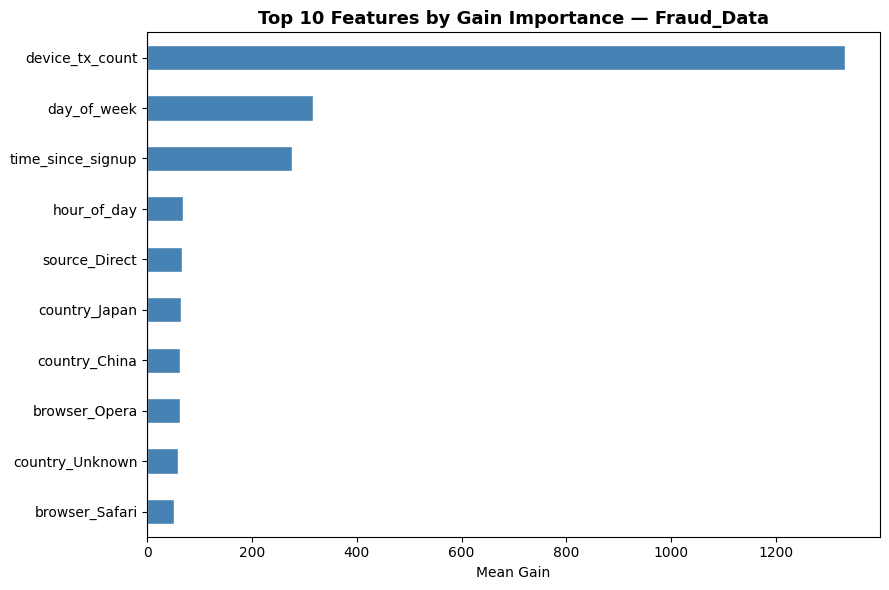

Saved: ../reports/figures/feat_importance_cc.png


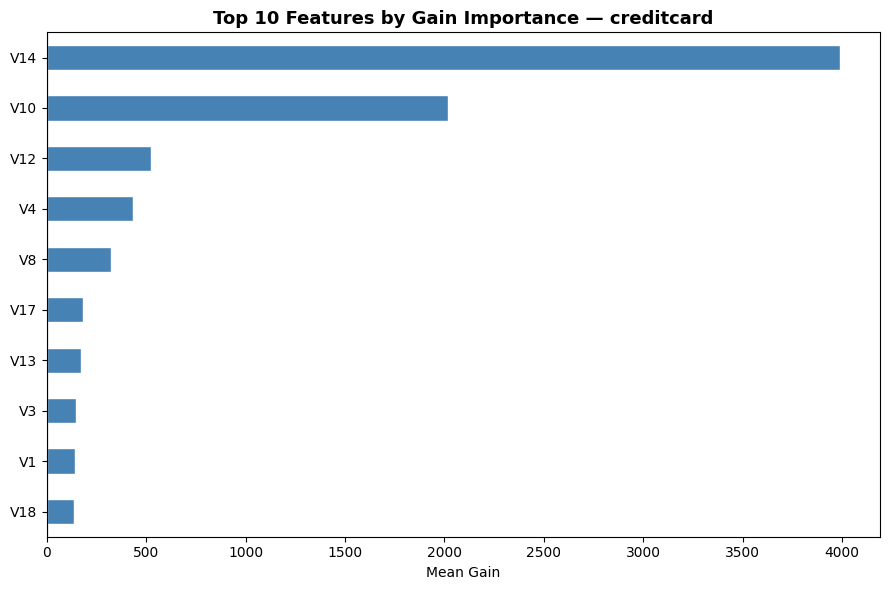

In [2]:
plot_feature_importance(
    xgb_fraud,
    feature_names=X_train_f.columns.tolist(),
    top_n=10,
    dataset_name="Fraud_Data",
    save_path='../reports/figures/feat_importance_fraud.png'
)

plot_feature_importance(
    xgb_cc,
    feature_names=X_train_c.columns.tolist(),
    top_n=10,
    dataset_name="creditcard",
    save_path='../reports/figures/feat_importance_cc.png'
)

explainers

In [4]:
def prepare_background(X: pd.DataFrame, n: int = 200, random_state: int = 42) -> pd.DataFrame:
    """
    Sample and cast background data to float64.
    
    Design choice: TreeExplainer requires a numeric float64 array.
    Boolean and object columns from get_dummies must be explicitly cast
    before passing as background — SHAP does not coerce dtypes silently.
    """
    sample = X.sample(n=n, random_state=random_state).copy()

    non_numeric = sample.select_dtypes(exclude=['number']).columns.tolist()
    if non_numeric:
        print(f"Casting non-numeric columns to float64: {non_numeric}")

    sample = sample.astype(float)
    return sample


bg_fraud = prepare_background(X_train_f, n=200)
bg_cc = prepare_background(X_train_c, n=200)

explainer_fraud = get_shap_explainer(xgb_fraud, bg_fraud)
explainer_cc = get_shap_explainer(xgb_cc,    bg_cc)

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


Casting non-numeric columns to float64: ['source_Ads', 'source_Direct', 'source_SEO', 'browser_Chrome', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_F', 'sex_M', 'country_Afghanistan', 'country_Albania', 'country_Algeria', 'country_Angola', 'country_Antigua and Barbuda', 'country_Argentina', 'country_Armenia', 'country_Australia', 'country_Austria', 'country_Azerbaijan', 'country_Bahamas', 'country_Bahrain', 'country_Bangladesh', 'country_Barbados', 'country_Belarus', 'country_Belgium', 'country_Belize', 'country_Benin', 'country_Bermuda', 'country_Bhutan', 'country_Bolivia', 'country_Bonaire; Sint Eustatius; Saba', 'country_Bosnia and Herzegowina', 'country_Botswana', 'country_Brazil', 'country_British Indian Ocean Territory', 'country_Brunei Darussalam', 'country_Bulgaria', 'country_Burkina Faso', 'country_Burundi', 'country_Cambodia', 'country_Cameroon', 'country_Canada', 'country_Cape Verde', 'country_Cayman Islands', 'country_Chile', 'country_China', 'c

computing SAHP values

In [5]:
shap_vals_fraud, X_shap_fraud = compute_shap_values(
    explainer_fraud, X_test_f.astype(float), sample_size=500
)

shap_vals_cc, X_shap_cc = compute_shap_values(
    explainer_cc, X_test_c.astype(float), sample_size=500
)

Sampled 500 rows for SHAP computation.
Computing SHAP values... (this may take a moment)
SHAP values computed. Shape: (500, 199)
Sampled 500 rows for SHAP computation.
Computing SHAP values... (this may take a moment)
SHAP values computed. Shape: (500, 30)


summary plots

Saved: ../reports/figures/shap_summary_fraud.png


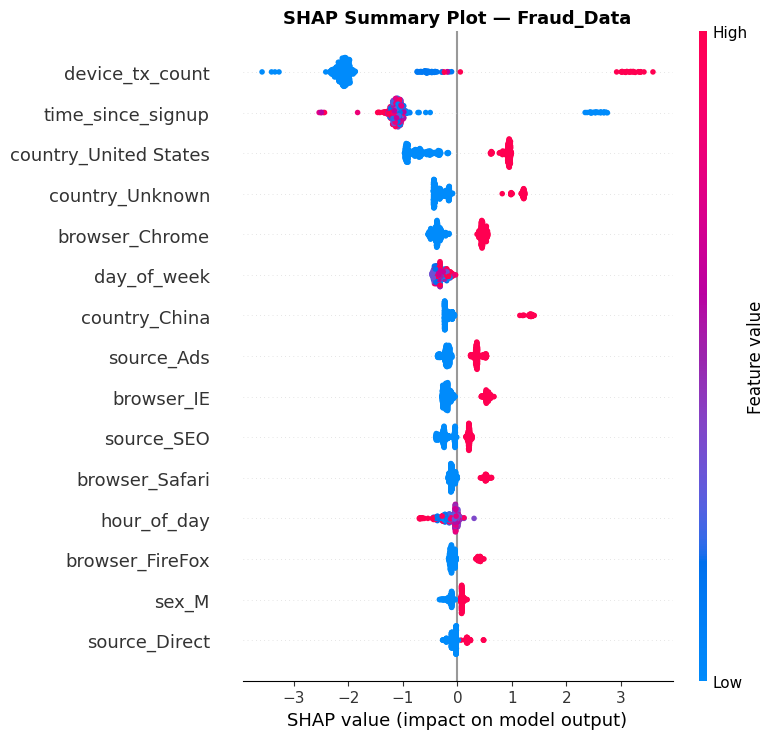

Saved: ../reports/figures/shap_summary_cc.png


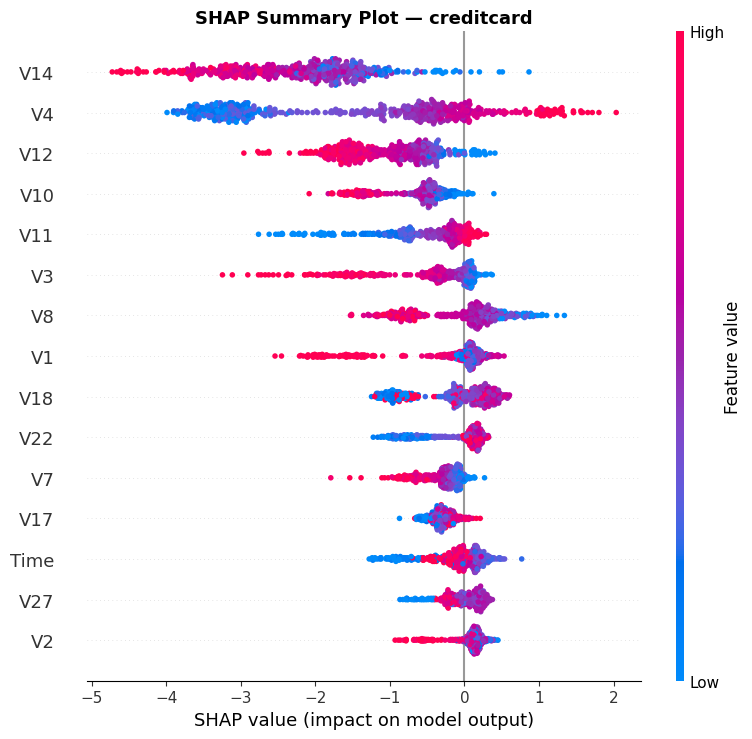

In [6]:
plot_shap_summary(
    shap_vals_fraud, X_shap_fraud,
    dataset_name="Fraud_Data",
    save_path='../reports/figures/shap_summary_fraud.png'
)

plot_shap_summary(
    shap_vals_cc, X_shap_cc,
    dataset_name="creditcard",
    save_path='../reports/figures/shap_summary_cc.png'
)

bar plots

Saved: ../reports/figures/shap_bar_fraud.png


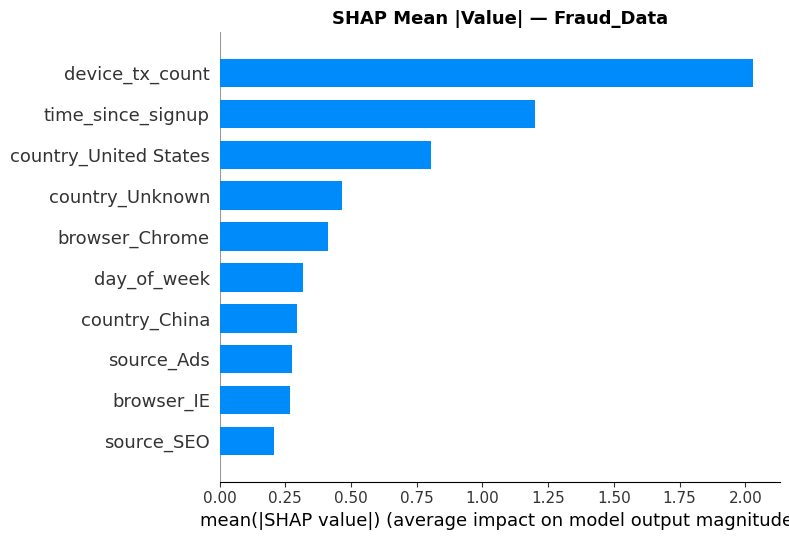

Saved: ../reports/figures/shap_bar_cc.png


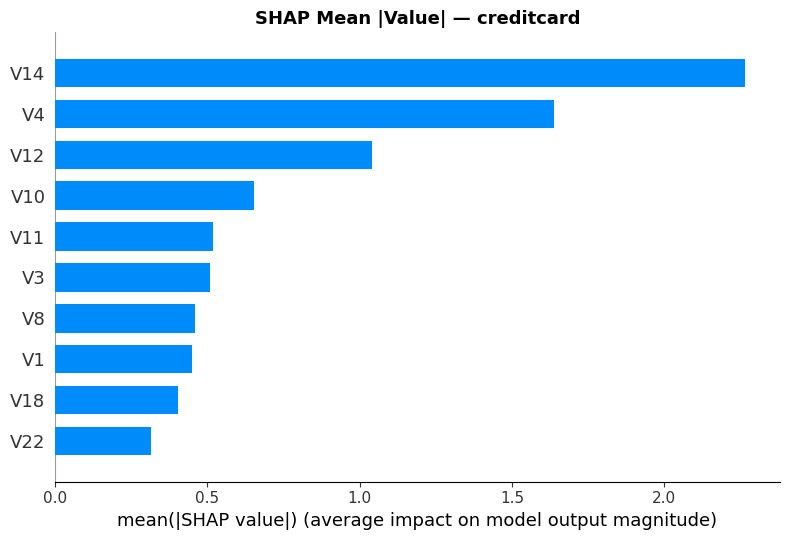

In [7]:
plot_shap_bar(
    shap_vals_fraud, X_shap_fraud,
    dataset_name="Fraud_Data",
    save_path='../reports/figures/shap_bar_fraud.png'
)

plot_shap_bar(
    shap_vals_cc, X_shap_cc,
    dataset_name="creditcard",
    save_path='../reports/figures/shap_bar_cc.png'
)

fund case indeces

In [8]:
print("=== Fraud_Data ===")
cases_fraud = find_case_indices(xgb_fraud, X_test_f, y_test_f)

print("\n=== creditcard ===")
cases_cc = find_case_indices(xgb_cc, X_test_c, y_test_c)

=== Fraud_Data ===
True Positive example found at index: 17 (1579 total available)
False Positive example found at index: 152 (241 total available)
False Negative example found at index: 2 (1251 total available)

=== creditcard ===
True Positive example found at index: 840 (87 total available)
False Positive example found at index: 165 (80 total available)
False Negative example found at index: 17046 (11 total available)


Compute full SHAP values for force plots (no sampling)

In [9]:
shap_vals_fraud_full, _ = compute_shap_values(
    explainer_fraud, X_test_f.astype(float))
shap_vals_cc_full, _ = compute_shap_values(
    explainer_cc,    X_test_c.astype(float))

Computing SHAP values... (this may take a moment)


100%|===================| 30193/30223 [08:35<00:00]        

SHAP values computed. Shape: (30223, 199)
Computing SHAP values... (this may take a moment)


100%|===================| 56902/56962 [121:20<00:07]        

SHAP values computed. Shape: (56962, 30)


Fraud_Data force & waterfall plots


───────────────────────────────────────────────────────
  Force Plot: True Positive — Fraud Correctly Caught — Fraud_Data
  Row index : 17
  Base value: 1.6754
───────────────────────────────────────────────────────


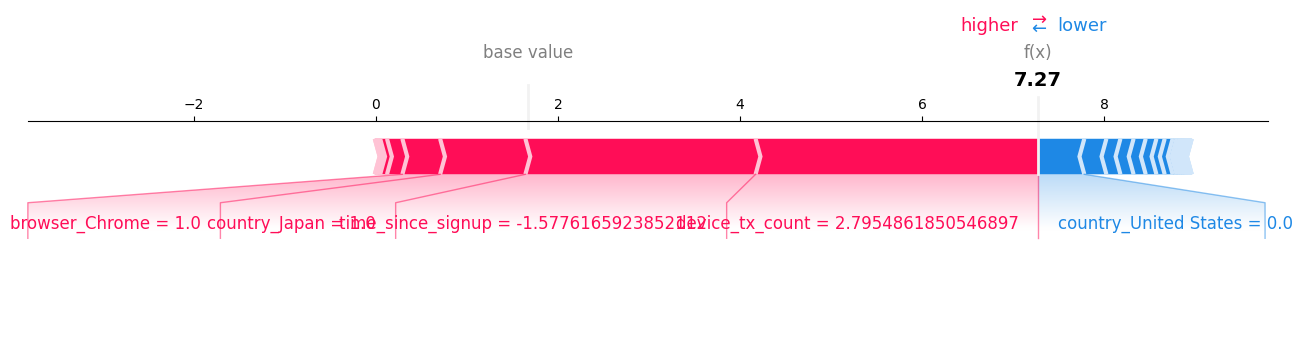

Saved: ../reports/figures/waterfall_fraud_tp.png


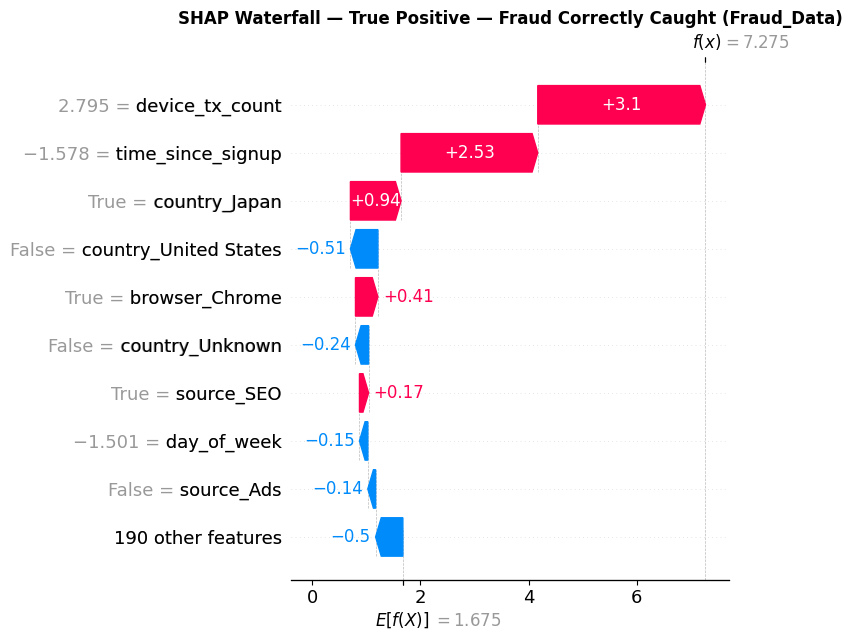


───────────────────────────────────────────────────────
  Force Plot: False Positive — Legitimate Flagged as Fraud — Fraud_Data
  Row index : 152
  Base value: 1.6754
───────────────────────────────────────────────────────


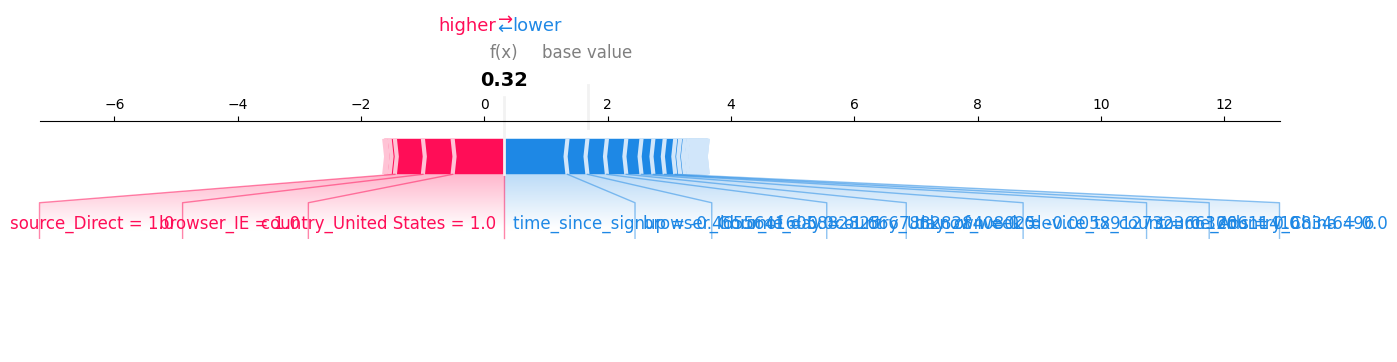

Saved: ../reports/figures/waterfall_fraud_fp.png


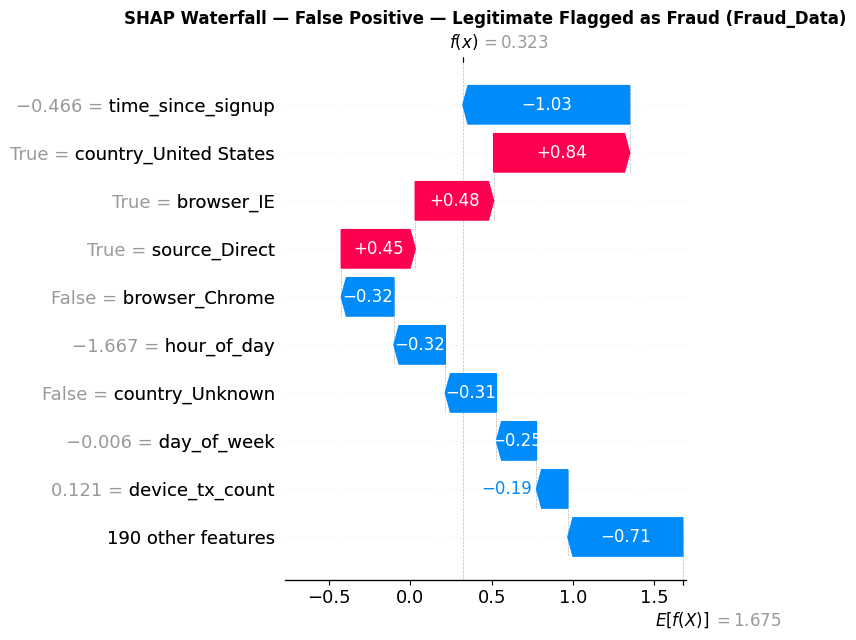


───────────────────────────────────────────────────────
  Force Plot: False Negative — Missed Fraud — Fraud_Data
  Row index : 2
  Base value: 1.6754
───────────────────────────────────────────────────────


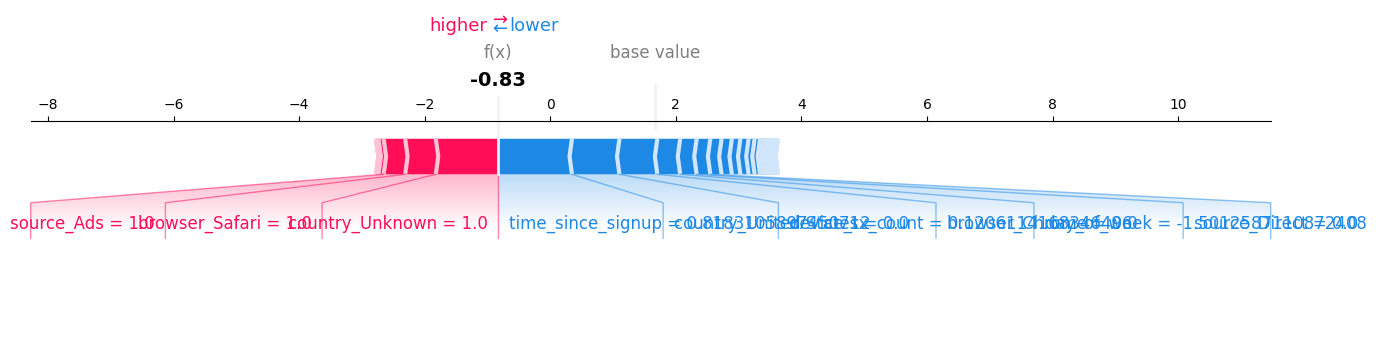

Saved: ../reports/figures/waterfall_fraud_fn.png


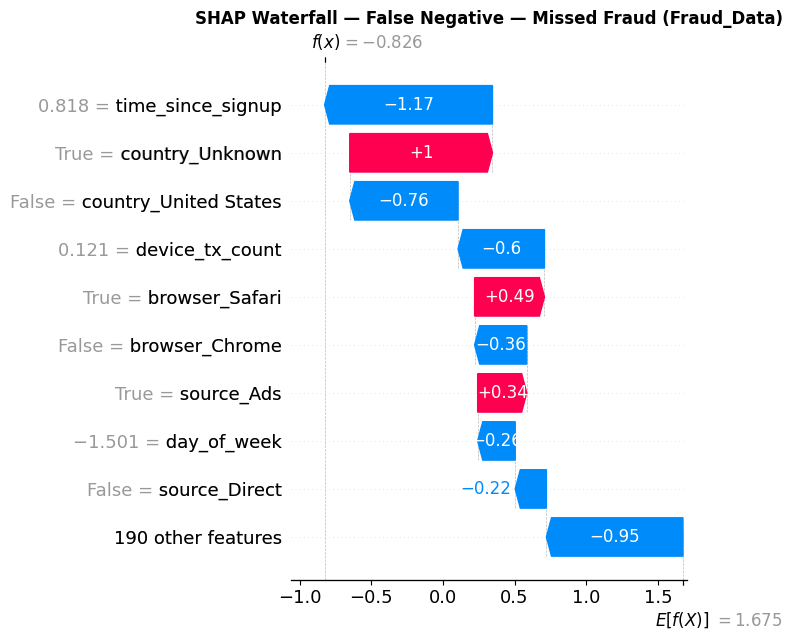

In [10]:
case_labels = {
    "tp": "True Positive — Fraud Correctly Caught",
    "fp": "False Positive — Legitimate Flagged as Fraud",
    "fn": "False Negative — Missed Fraud"
}

for case_key, label in case_labels.items():
    idx = cases_fraud[case_key]

    plot_force(
        explainer_fraud, shap_vals_fraud_full,
        X_test_f, row_idx=idx,
        case_label=label, dataset_name="Fraud_Data"
    )

    plot_shap_waterfall(
        explainer_fraud, shap_vals_fraud_full,
        X_test_f, row_idx=idx,
        case_label=label, dataset_name="Fraud_Data",
        save_path=f'../reports/figures/waterfall_fraud_{case_key}.png'
    )

credit force & waterfall plots


───────────────────────────────────────────────────────
  Force Plot: True Positive — Fraud Correctly Caught — creditcard
  Row index : 840
  Base value: 0.0509
───────────────────────────────────────────────────────


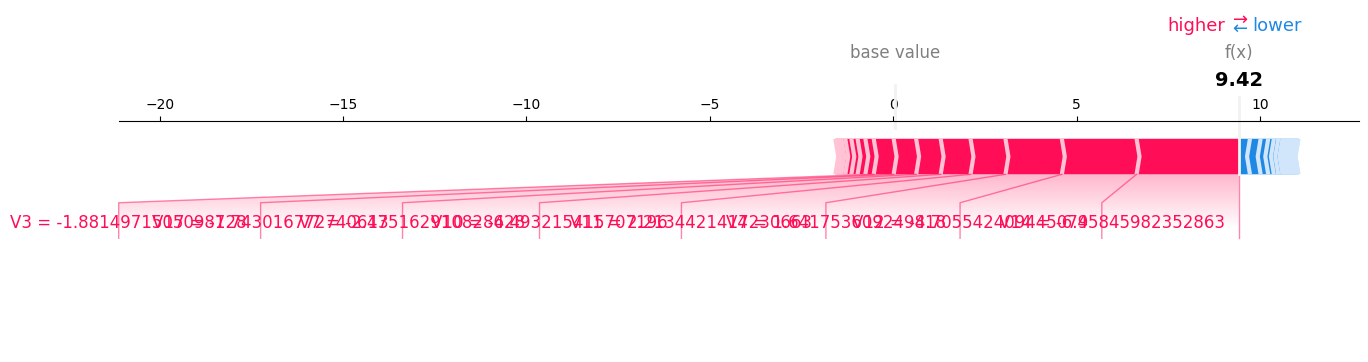

Saved: ../reports/figures/waterfall_cc_tp.png


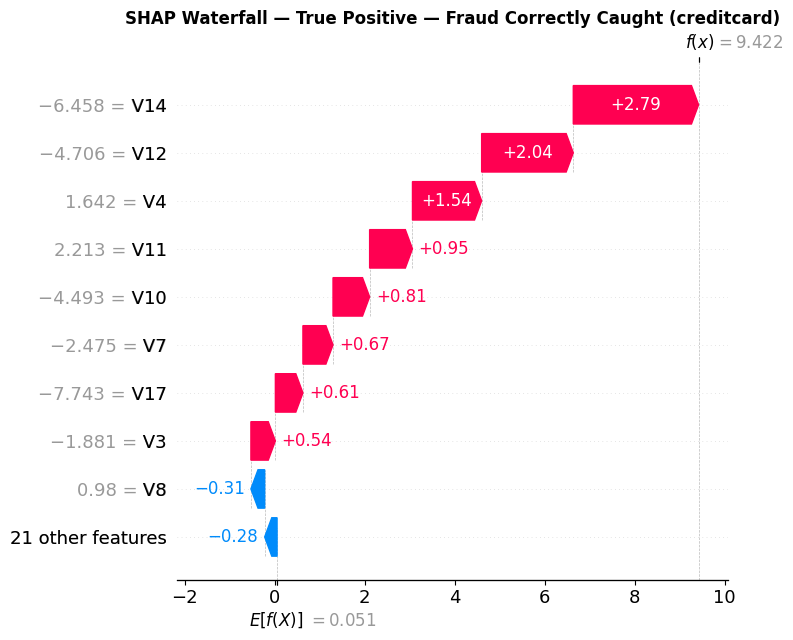


───────────────────────────────────────────────────────
  Force Plot: False Positive — Legitimate Flagged as Fraud — creditcard
  Row index : 165
  Base value: 0.0509
───────────────────────────────────────────────────────


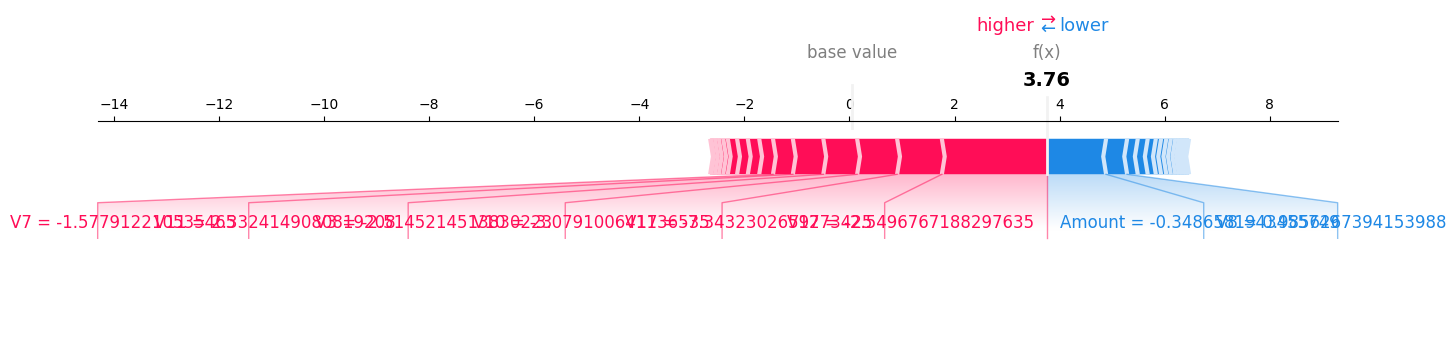

Saved: ../reports/figures/waterfall_cc_fp.png


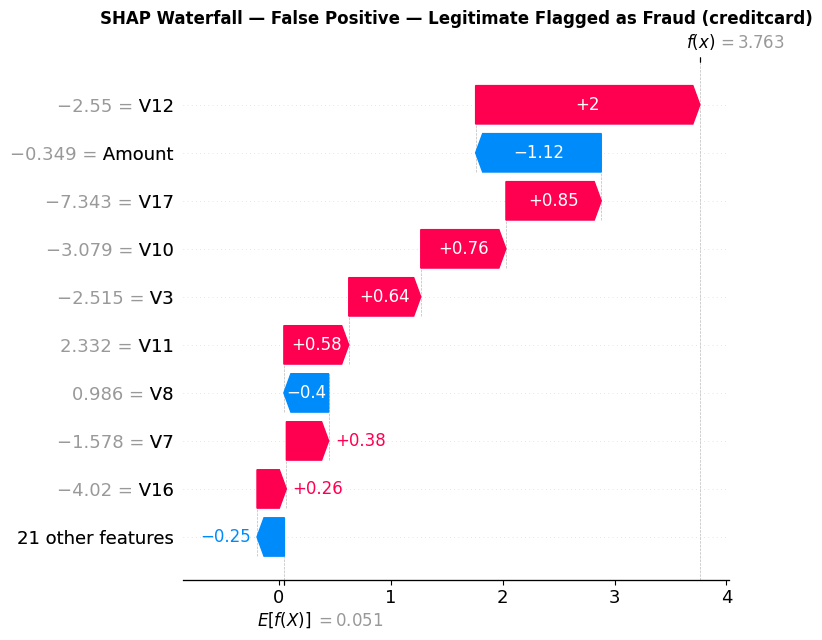


───────────────────────────────────────────────────────
  Force Plot: False Negative — Missed Fraud — creditcard
  Row index : 17046
  Base value: 0.0509
───────────────────────────────────────────────────────


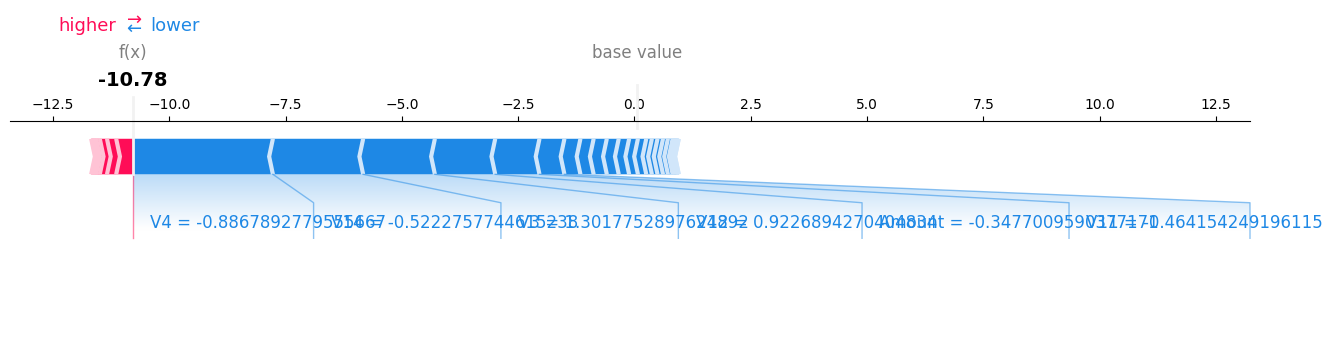

Saved: ../reports/figures/waterfall_cc_fn.png


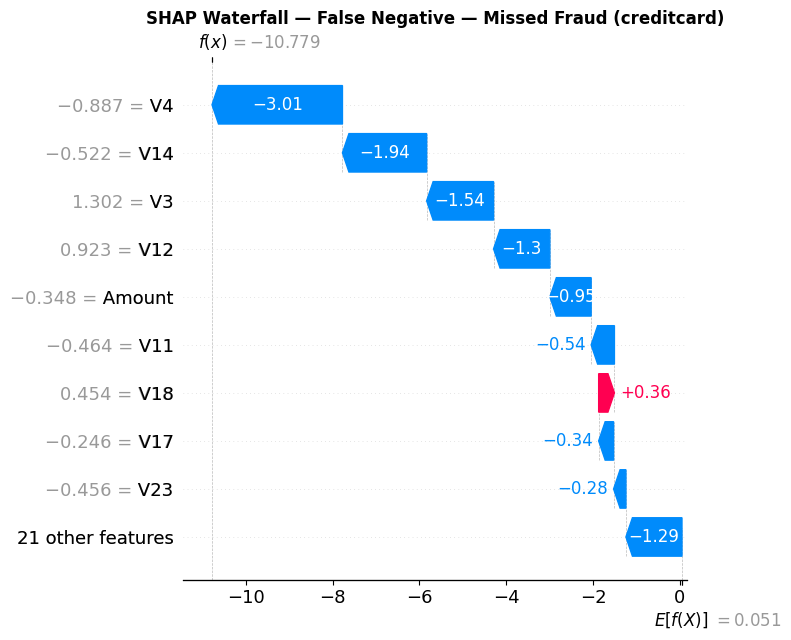

In [11]:
for case_key, label in case_labels.items():
    idx = cases_cc[case_key]

    plot_force(
        explainer_cc, shap_vals_cc_full,
        X_test_c, row_idx=idx,
        case_label=label, dataset_name="creditcard"
    )

    plot_shap_waterfall(
        explainer_cc, shap_vals_cc_full,
        X_test_c, row_idx=idx,
        case_label=label, dataset_name="creditcard",
        save_path=f'../reports/figures/waterfall_cc_{case_key}.png'
    )

Business Recommendations

1. Flag accounts transacting within 2 hours of signup for step-up authentication
SHAP shows time_since_signup as the strongest single predictor in Fraud_Data.
Trigger SMS OTP or document verification for any purchase made within 2 hours
of account creation. This directly targets the credential abuse pattern
where fraudsters create and immediately exploit accounts.

2. Quarantine devices with high transaction counts pending manual review
device_tx_count drives fraud predictions consistently. A device appearing
across more than N unique users (threshold to be calibrated on production data)
should be flagged for review and temporarily rate-limited, disrupting
coordinated fraud ring operations.

3. Apply geolocation-based risk tiers
Country SHAP values reveal that certain geographies consistently push
predictions toward fraud. Implement a tiered verification policy:
high-risk countries require additional authentication steps rather than
outright blocking, preserving legitimate customer access while raising
the cost of fraud.

4. Investigate false negative patterns for model retraining triggers
SHAP waterfall plots on false negatives reveal which features the model
under-weighted on missed fraud cases. These patterns should be logged
in production and used to trigger periodic retraining when their frequency
crosses a threshold — building a self-improving detection loop.

5. Use SHAP scores as a real-time risk signal in the transaction API
Rather than a binary fraud/not-fraud output, expose the top 3 SHAP
contributors per transaction to downstream fraud analysts. This accelerates
manual review by surfacing why a transaction was flagged, reducing
investigation time and improving analyst trust in the model.